# Flat and two-layer LMDP examples

This notebook runs the current four-room examples in small, inspectable steps.

In [1]:
from pathlib import Path
import runpy
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

# This works whether Jupyter starts in the repository root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from andrew_mlmdp import (
    Maze,
    build_two_layer_model,
    compute_layer_one_plan,
    controlled_dynamics,
    desirability_grid,
    plot_controlled_dynamics,
    plot_trajectory,
    sample_rollout,
    sample_hierarchical_rollout,
    solve_desirability,
)

## Exact two-layer model

In [ ]:
maze = Maze.from_file(PROJECT_ROOT / "mazes" / "four_rooms.txt")
goal = (10, 9)

subgoal_labels = ("A", "B", "C", "D", "E", "F")
subgoals = (
    (0, 0),
    (9, 2),
    (2, 3),
    (3, 7),
    (9, 7),
    (7, 9),
)
beta = 10.0  # Our convention; the paper specifies only proportionality.
hierarchical_start = (1, 0)

two_layer_model = build_two_layer_model(maze, subgoals, goal, off_target_reward=0)
initial_plan = compute_layer_one_plan(
    two_layer_model,
    hierarchical_start,
    beta=beta,
)

print("target order:", subgoal_labels + ("goal",))
print("layer-1 basis shape:", two_layer_model.layer_one_desirability_basis.shape)
print("layer-2 passive shape:", two_layer_model.layer_two_passive.shape)

target order: ('A', 'B', 'C', 'D', 'E', 'F', 'goal')
layer-1 basis shape: (96, 7)
layer-2 passive shape: (7, 6)


### Layer-2 passive and controlled dynamics

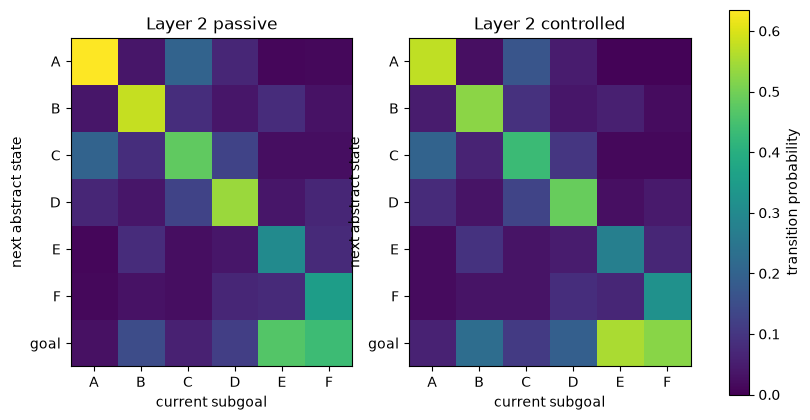

In [8]:
abstract_labels = subgoal_labels + ("goal",)
matrix_maximum = max(
    two_layer_model.layer_two_passive.max(),
    two_layer_model.layer_two_controlled.max(),
)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, matrix, title in (
    (axes[0], two_layer_model.layer_two_passive, "Layer 2 passive"),
    (axes[1], two_layer_model.layer_two_controlled, "Layer 2 controlled"),
):
    image = ax.imshow(matrix, cmap="viridis", vmin=0.0, vmax=matrix_maximum)
    ax.set_xticks(np.arange(len(subgoal_labels)), subgoal_labels)
    ax.set_yticks(np.arange(len(abstract_labels)), abstract_labels)
    ax.set_xlabel("current subgoal")
    ax.set_ylabel("next abstract state")
    ax.set_title(title)

fig.colorbar(image, ax=axes, label="transition probability")
plt.show()

### Initial first-hit distribution, reward inpainting, and task weights

 target   passive  controlled  reward    weight
    A      0.563       0.500     -0.630     0.163
    B      0.047       0.056      0.087     0.372
    C      0.244       0.238     -0.057     0.317
    D      0.082       0.091      0.094     0.375
    E      0.015       0.022      0.075     0.367
    F      0.015       0.023      0.077     0.368
 goal      0.035       0.071      1.000     1.000


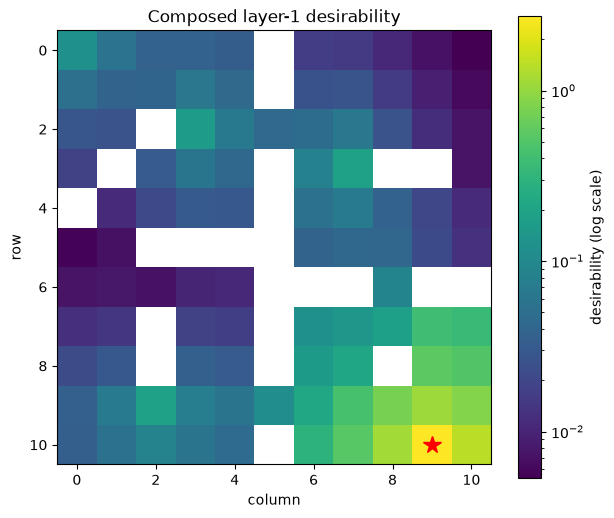

In [9]:
print(" target   passive  controlled  reward    weight")
for label, passive, controlled_value, reward, weight in zip(
    abstract_labels,
    initial_plan.passive_abstract,
    initial_plan.controlled_abstract,
    initial_plan.inpainted_rewards,
    initial_plan.weights,
):
    print(
        f" {label:>4}    {passive:7.3f}     {controlled_value:7.3f}"
        f"    {reward:7.3f}   {weight:7.3f}"
    )

composed_grid = desirability_grid(maze, initial_plan.physical_desirability)
positive_values = composed_grid[np.isfinite(composed_grid) & (composed_grid > 0.0)]
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(
    composed_grid,
    cmap="viridis",
    norm=LogNorm(vmin=positive_values.min(), vmax=positive_values.max()),
)
ax.plot(goal[1], goal[0], marker="*", color="red", markersize=13)
ax.set_title("Composed layer-1 desirability")
ax.set_xlabel("column")
ax.set_ylabel("row")
fig.colorbar(image, ax=ax, label="desirability (log scale)")
plt.show()

### Hierarchical rollout

In [ ]:
hierarchical_rollout = sample_hierarchical_rollout(
    two_layer_model,
    hierarchical_start,
    beta=beta,
    seed=28,
)

print("status:", hierarchical_rollout.status)
print("physical steps:", hierarchical_rollout.physical_steps)
print("zero-time subgoal accesses:", hierarchical_rollout.abstract_accesses)
for label, coordinate in zip(subgoal_labels, subgoals):
    print(f"{label}: {hierarchical_rollout.subgoal_accesses.count(coordinate)} accesses")

ax = plot_trajectory(maze, hierarchical_rollout.trajectory, goal=goal)
for label, (row, column) in zip(subgoal_labels, subgoals):
    ax.scatter(column, row, s=60, facecolors="none", edgecolors="darkorange")
    ax.text(column + 0.13, row - 0.13, label, color="darkorange")
ax.set_title(
    f"Hierarchical rollout: {hierarchical_rollout.status} "
    f"({hierarchical_rollout.physical_steps} steps)"
)
plt.show()

## Flat one-layer model

In [ ]:
maze = Maze.from_file(PROJECT_ROOT / "mazes" / "four_rooms.txt")
goal = (10, 9)

print(f"maze shape: {maze.shape}")
print(f"free states: {len(maze.free_cells)}")
print(f"goal state: {maze.state_index(goal)}")

## Exact desirability

In [ ]:
desirability = solve_desirability(maze, goal)
grid = desirability_grid(maze, desirability)

fig, ax = plt.subplots(figsize=(7, 6))
# Log scaling reveals structure among the very small values far from the goal.
positive_values = grid[np.isfinite(grid) & (grid > 0.0)]
log_scale = LogNorm(vmin=positive_values.min(), vmax=positive_values.max())
image = ax.imshow(grid, cmap="viridis", norm=log_scale)
ax.plot(goal[1], goal[0], marker="*", color="red", markersize=13)
ax.set_title("Exact desirability")
ax.set_xlabel("column")
ax.set_ylabel("row")
fig.colorbar(image, ax=ax, label="desirability (log scale)")
plt.show()

## Controlled next-state probabilities

In [ ]:
controlled = controlled_dynamics(maze, desirability)
ax = plot_controlled_dynamics(maze, controlled, goal=goal)
plt.show()

## Sample a rollout

In [ ]:
start = (0, 0)
trajectory = sample_rollout(
    maze,
    controlled,
    start,
    goal,
    seed=7,
)

print(f"reached goal: {trajectory[-1] == goal}")
print(f"steps: {len(trajectory) - 1}")
ax = plot_trajectory(maze, trajectory, goal=goal)
plt.show()

## Run the figure scripts

These scripts repeat the controlled-dynamics and rollout examples and save their PNGs in `output/`.

In [ ]:
example_scripts = [
    "plot_flat_policy.py",
    "plot_sample_rollout.py",
    "plot_two_layer.py",
]

for script_name in example_scripts:
    runpy.run_path(
        str(PROJECT_ROOT / "experiments" / script_name),
        run_name="__main__",
    )